In [1]:
#imports
import os
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim

from src.config import BaseConfig
from src.visualization import Visualizer
from data import load_images, split_data, compute_mean_std, get_test_transform, get_train_transform, ImgDataset
from models import get_resnet18
from train import run_epochs
from eval import run_test
from cam import compute_cam

torch.manual_seed(BaseConfig.SEED)
random.seed(BaseConfig.SEED)

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

## Loading images and creating labels
Labels were mapped to an integer (subsequently in range 0-9) and stored in a dictionary. To make life easier, a reverse dictionary was also implemented.

In [3]:
project_path = os.path.dirname(os.getcwd())
data_path = os.path.join(project_path, 'data')
data, labels, class_to_num = load_images(data_path)
num_to_class = {y:x for x,y in class_to_num.items()}

# Dataset Evaluation
### Sample visualisation
Images vary in quality. Some are digitally written, some are handwritten on a plain background and some are handwritten on a square paper. If images are handwritten, the background appears more gray than white.

All images have the same size (H, W): (130, 160)


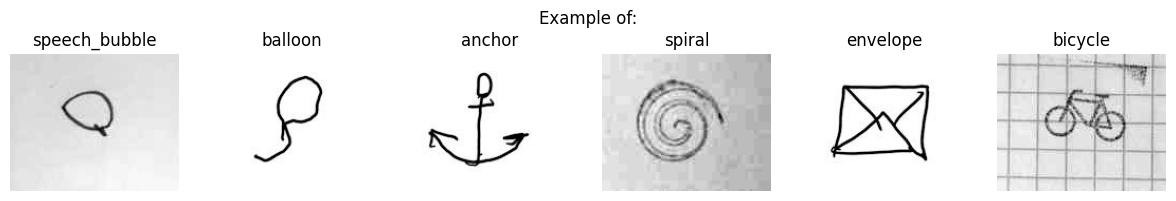

In [4]:
visualizer = Visualizer(data,labels,num_to_class)
visualizer.show_image_size_info()
visualizer.show_images(True, 6)

There are 10 unique classes, displayed below.

In [5]:
print(f"{len(class_to_num)} classes: {list(class_to_num.keys())}")

10 classes: ['anchor', 'balloon', 'bicycle', 'envelope', 'paper_boat', 'peace_symbol', 'smiley', 'speech_bubble', 'spiral', 'thumb']


Data is balanced, although dataset is VERY small - the number of samples for each class is between 41 and 44. One sample is a 2D array of values between 0-255.

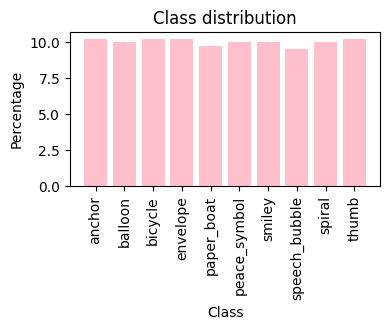

In [6]:
visualizer.show_class_distribution()

### Laplace variance
Laplace variance is a metric, measuring how blurry an image is. A higher variance means a sharper image, a lower variance means a blurrier image. The distribution has a very high peak around 0, and a smaller, broader peak around 2000-3000. Identifying a threshold is not obvious, so for the sake of this experiment, threshold will be defined by 1000, since no images are observed with this variance. Images with variance lower than threshold are classified as blurry and images with variance higher than threshold as sharp. This threshold is not universal and depends on the dataset.

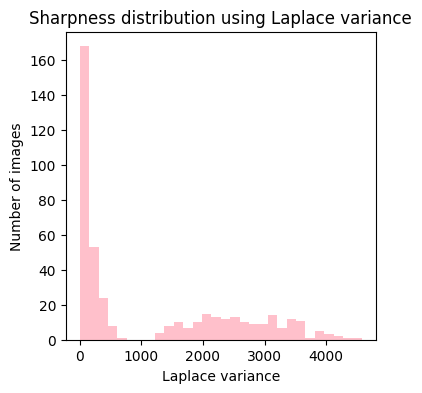

In [7]:
visualizer.show_sharpness_distribution()

### Blurriest vs sharpest image
Laplace variance classified 5 images on the first row as the blurriest and 5 on the second row as the sharpest. This corresponds to what a human would classify as blurry and sharp. The 3 images on the third row are nearest to the threshold, meaning they represent borderline cases between blurry and sharp. They appear sharp visually, so the threshold can be probably slightly decreased.

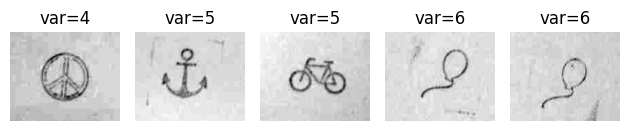

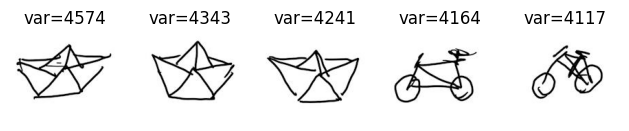

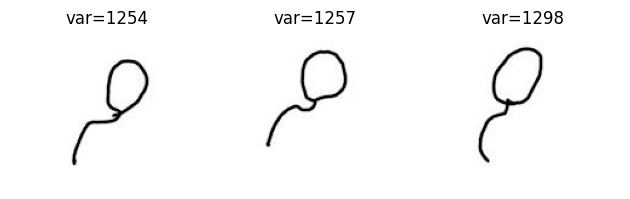

In [8]:
visualizer.show_blurriest_images(5)
visualizer.show_sharpest_images(5)
visualizer.show_images_near_threshold(1000, 3)

With the threshold set to 1000, all images appear visually sharp. However, after slightly decreasing it to 950, the first visually blurry image appears with the laplace variance of 685. Next image, visually sharp, has a variance of 1254. This confirms that threshold of 1000 is reasonable.

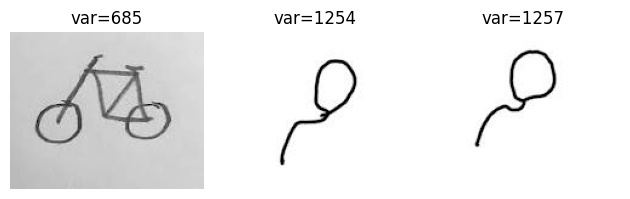

In [9]:
visualizer.show_images_near_threshold(950, 3)

### Brightness distribution
The images are in grayscale - the higher pixel value, the lighter pixel is. The mean pixel value in an image can help identify if image is handwritten or digitized - handwritten images could have darker, grayer background. Grid lines can further decrease pixel value, decreasing overall brightness.

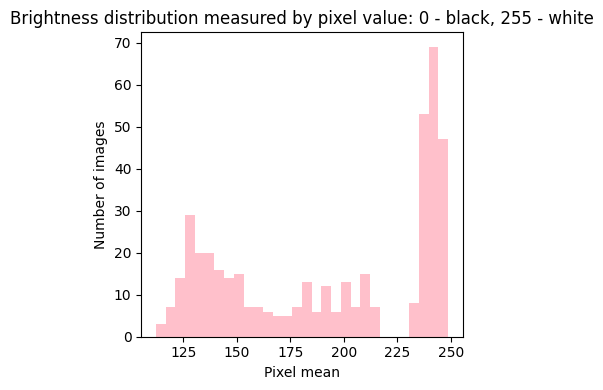

In [10]:
visualizer.show_brightness_distribution()

# Preprocessing

Pipeline:
split to train, test, val --> load to Dataset object --> transformation applied on __getitem__() --> DataLoader batching --> training

Mean and standard deviation need to be calculated on the train set, after distinction of test and validation set and after converting pixel values from 0-255 to 0-1.

In [11]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(data, labels)
mean, std = compute_mean_std(X_train)

I decided to augment the data with geometric transformations. Color and appearance adjustments aren't appropriate, since the images are in greyscale and are very simple. More aggresive technics, such as cutouts seem also unnecessary.
Only train data will be augmented. The original images are never horizontally flipped, so appplying horizontal flips would introduce orientations that do not appear in test data. Horizontal flipping can only be applied to symmetric data, where transformation doesn't change the semantic meaning.

### Flippable classes
After carefully assessing, proceeding classes are defined as symmetric, and therefore flippable: envelope, paper_boat, peace_symbol, smiley and speech


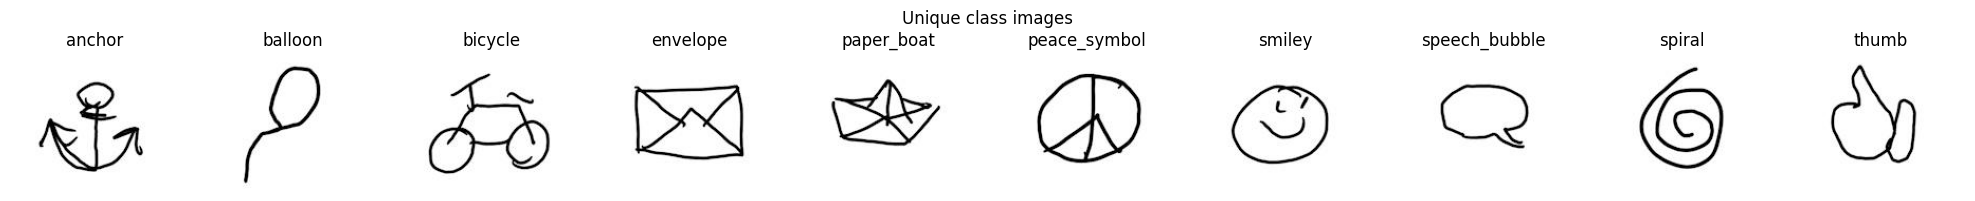

['anchor', 'envelope', 'paper_boat', 'peace_symbol', 'smiley']


In [12]:
visualizer.show_unique_images()
flippable_classes = [0,3,4,5,6]
print([num_to_class[x] for x in flippable_classes])

# Dataset
The dataset class loads image data stored as NumPy arrays, corresponding labels, and the required transforms. Using `__getitem__` it returns transformed tensor data and labels. Following transforms are used:
- torchvision.transforms.ToTensor - converts a uint8 numpy array (H, W) in the range [0-255] to a float32 tensor (C, H, W) in the range [0.0-1.0].
- torchvision.transforms.RandomAffine - applies random geometric transformations. Following parameters are used: rotation from -15 to 15 degrees, translation (shifting horizontally and vertically) with values: -img_width * 0.05 < horizontal shift < img_width * 0.05,  -img_height * 0.05 < vertical shift < img_height * 0.05, scaling from 0.9 to 1.1 of image size.
- torchvision.transforms.Lambda - self-defined transform to repeat the single grayscale channel 3 times, producing a 3-channel tensor. This is necessary, as ResNet was trained on RGB images, expecting input of 3 channels.
- torchvision.transforms.Normalize - normalizes the [0.0-1.0] tensors by mean and standard deviation previously calculated on the train data. It normalizes data per channel.

In [13]:
transform_flip = get_train_transform(mean, std, True)
transform_noflip = get_train_transform(mean, std, False)
transform_eval = get_test_transform(mean, std)

test_set = ImgDataset(X_test, y_test, False, transform_eval = transform_eval)
train_set = ImgDataset(X_train, y_train, True, transform_flip=transform_flip, transform_noflip=transform_noflip, flippable_classes=flippable_classes)
val_set = ImgDataset(X_val, y_val, False, transform_eval=transform_eval)

In [14]:
print(f"Train/Test/Val:{len(train_set)}/{len(test_set)}/{len(val_set)}")

Train/Test/Val:301/65/65


In [15]:
train_loader  = DataLoader(train_set, batch_size=BaseConfig.BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BaseConfig.BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_set, batch_size=BaseConfig.BATCH_SIZE, shuffle=False)

# Sanity check
Checklist to confirm that data pipeline is correct:
- Pixel value is in range 0-255 (before transforms)
- Data sample is of shape (130, 160) (H, W)
- DataLoader returns batches of shape (16, 3, 130, 160) (B, C, H, W)
- Pixel values are properly normalized after transforms
- Labels match images
- Sample images after transform look visually correct


Minimum pixel value in data[0]: 0
Maximum pixel value in data[0]: 255
Shape of data sample: (130, 160)
Shape of batch sample: torch.Size([16, 3, 130, 160])
Minimum pixel value in image from batch: -2.623666763305664
Maximum pixel value in image from batch: 0.281144917011261


Text(0.5, 1.0, 'anchor')

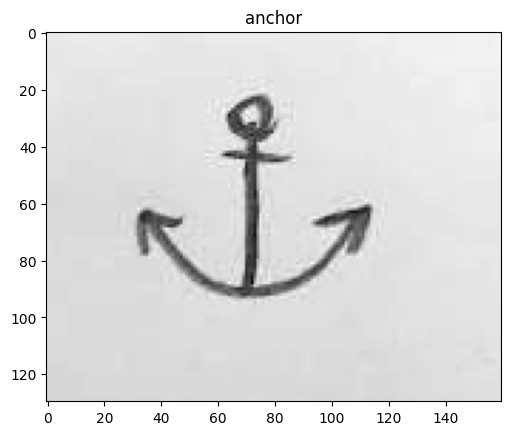

In [16]:
print(f"Minimum pixel value in data[0]: {np.min(data[0])}")
print(f"Maximum pixel value in data[0]: {np.max(data[0])}")
print(f"Shape of data sample: {data[0].shape}")
X, y = next(iter(val_loader))
print(f"Shape of batch sample: {X.shape}")
print(f"Minimum pixel value in image from batch: {torch.min(X[0][0])}")
print(f"Maximum pixel value in image from batch: {torch.max(X[0][0])}")
plt.imshow(X[0][0], cmap='gray')
plt.title(num_to_class[int(y[0])])

# Model
## Which approach performs better as a feature extraction method for classification on this dataset?
Two training approaches are used, with the same number of epochs, the same loss function and the same optimizer to ensure a fair comparison. Models were trained on training set and evaluated on validation set after each epoch. Model selection was based on a validation performance (accuracy, as the dataset is balanced). The test set was only used for the final evaluation. The goal of evaluating the models, is to answer the question above.

## Approach nr. 1: Retraining the entire model
The results are very good, with validation accuracy reaching 1.0. Training accuracy also reaches 1.0, indicating, that the model fits the data well. However, such strong performance should also raise suspicion: is this caused by overfitting, data leakage, very simple dataset or low variability of images? Further assessment on test data is required.

In [17]:
model = get_resnet18(len(class_to_num), False)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=BaseConfig.LR, momentum=BaseConfig.MOMENTUM)
optimizer = optim.SGD(model.parameters(), lr=BaseConfig.LR, momentum=BaseConfig.MOMENTUM)

history = run_epochs(BaseConfig.EPOCHS, train_loader, val_loader, model, optimizer, criterion, device)

Epoch 1/10 | train loss: 2.1146, acc: 0.2757 | val loss: 1.6207, acc: 0.4769
Epoch 2/10 | train loss: 0.9957, acc: 0.8140 | val loss: 0.4890, acc: 0.8923
Epoch 3/10 | train loss: 0.3823, acc: 0.9502 | val loss: 0.1380, acc: 0.9692
Epoch 4/10 | train loss: 0.1741, acc: 0.9734 | val loss: 0.0966, acc: 1.0000
Epoch 5/10 | train loss: 0.1071, acc: 0.9867 | val loss: 0.0491, acc: 1.0000
Epoch 6/10 | train loss: 0.0839, acc: 0.9900 | val loss: 0.0281, acc: 1.0000
Epoch 7/10 | train loss: 0.0599, acc: 0.9934 | val loss: 0.0234, acc: 1.0000
Epoch 8/10 | train loss: 0.0418, acc: 1.0000 | val loss: 0.0199, acc: 1.0000
Epoch 9/10 | train loss: 0.0337, acc: 1.0000 | val loss: 0.0178, acc: 1.0000
Epoch 10/10 | train loss: 0.0271, acc: 1.0000 | val loss: 0.0141, acc: 1.0000


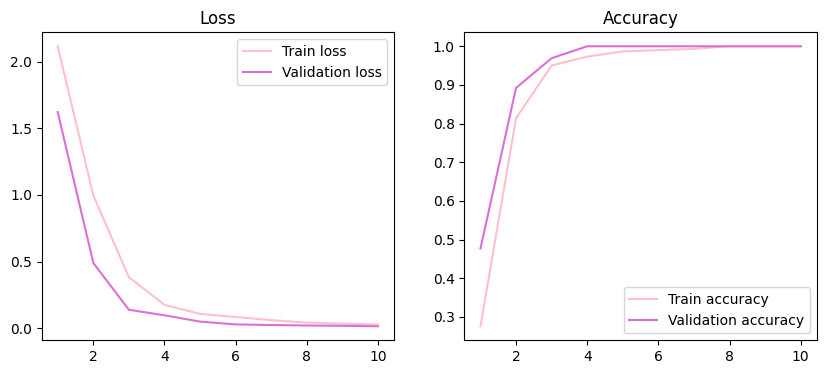

In [18]:
visualizer.show_training_process(history)

## Approach nr. 2: Fine-tuning with frozen backbone
In this approach, train and validation accuracy reach about 0.87. It is worse than the previous approach, indicating that this approach is less adaptable, as only the final classification layer is trained while the feature extractor remains fixed. It is also worth noting that train accuracy is worse than validation accuracy. This is expected, because augmentation is applied only to train dataset, making it more difficult. The validation dataset contains unmodified, simpler images.

In [19]:
model_fb = get_resnet18(len(class_to_num), True)

model_fb = model_fb.to(device)

criterion_fb = nn.CrossEntropyLoss()

optimizer_fb = optim.SGD(model_fb.fc.parameters(), lr=BaseConfig.LR, momentum=BaseConfig.MOMENTUM)

In [20]:
history = run_epochs(BaseConfig.EPOCHS, train_loader, val_loader, model_fb, optimizer_fb, criterion_fb, device)

Epoch 1/10 | train loss: 2.3198, acc: 0.1262 | val loss: 2.1591, acc: 0.2615
Epoch 2/10 | train loss: 1.9121, acc: 0.3355 | val loss: 1.8715, acc: 0.3692
Epoch 3/10 | train loss: 1.5669, acc: 0.5781 | val loss: 1.5089, acc: 0.6462
Epoch 4/10 | train loss: 1.3287, acc: 0.6545 | val loss: 1.2133, acc: 0.7077
Epoch 5/10 | train loss: 1.1432, acc: 0.7309 | val loss: 1.0504, acc: 0.7538
Epoch 6/10 | train loss: 1.0337, acc: 0.7575 | val loss: 0.9926, acc: 0.7538
Epoch 7/10 | train loss: 0.9209, acc: 0.8073 | val loss: 0.8665, acc: 0.8154
Epoch 8/10 | train loss: 0.9011, acc: 0.7874 | val loss: 0.8335, acc: 0.7846
Epoch 9/10 | train loss: 0.8437, acc: 0.8173 | val loss: 0.7875, acc: 0.8308
Epoch 10/10 | train loss: 0.7691, acc: 0.8272 | val loss: 0.7089, acc: 0.8769


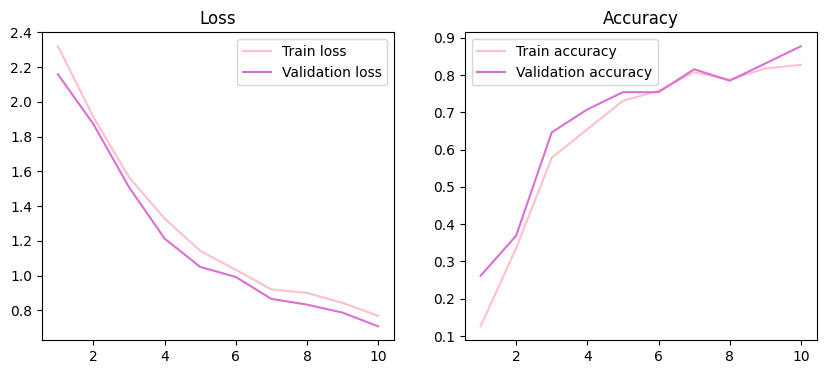

In [21]:
visualizer.show_training_process(history)

# Evaluation
## Metrics
To assess the model, primary metric used is accuracy. The dataset is balanced, so this is accurate. Additionaly, confusion matrix is displayed, showing common misclassifications.

## Approach nr. 1: Entire model retrained

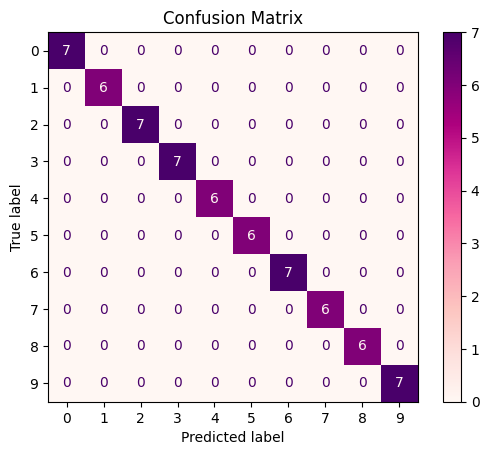

Test accuracy: 1.0


In [22]:
predictions, targets, wrong_idxs = run_test(model, test_loader, device)
visualizer.show_confusion_matrix(predictions, targets)

### Approach nr. 2: Model fine-tuned with frozen backbone

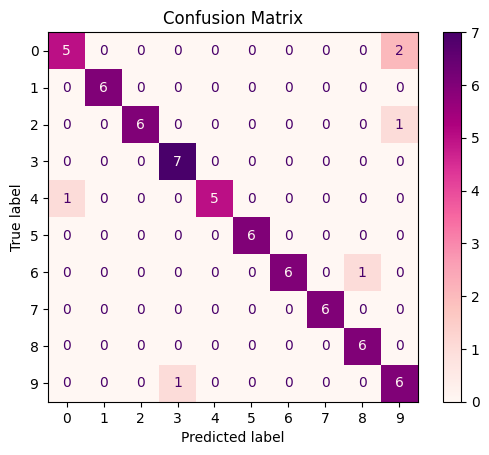

Test accuracy: 0.9077


In [23]:
predictions, targets, wrong_idxs = run_test(model_fb,test_loader, device)
visualizer.show_confusion_matrix(predictions, targets)

### Example of misclassified images (p: predicted label, t:true label)
The model misclassified both handwritten and digitally written images. This means that errors aren't caused by the type of image.

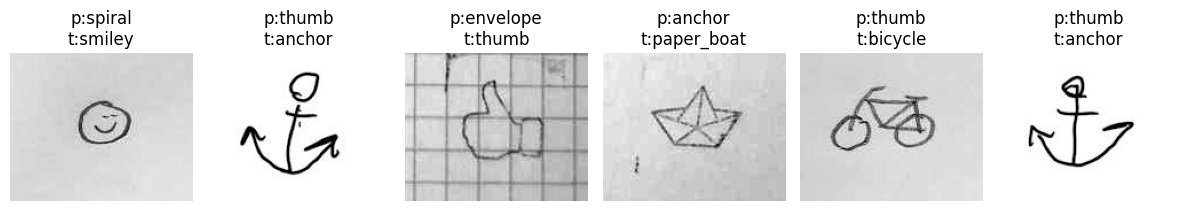

In [24]:
visualizer.show_misclassified_images(X_test, predictions, targets, wrong_idxs,10)

# Bonus: Class Activation Mapping
CAM is used to visualize which region of the image contribute to the model's prediction. It combines the last convolutional layer (the feature maps) with the last fully connected layer, linking **what the model sees** and **what is important for the given class**. To make the CAM result interpretable, CAM is passed through a ReLu function, resized to the original image, normalized to the range of 0-1 and overlaid on the input image as a heatmap.

### Correct Predictions

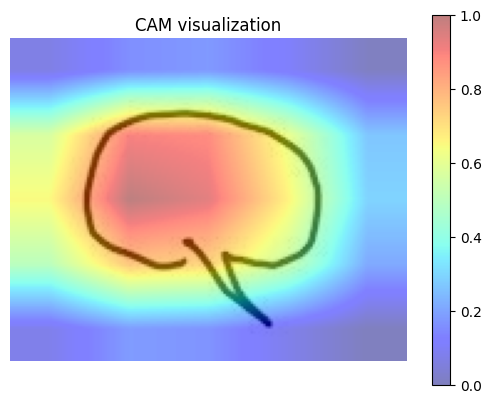

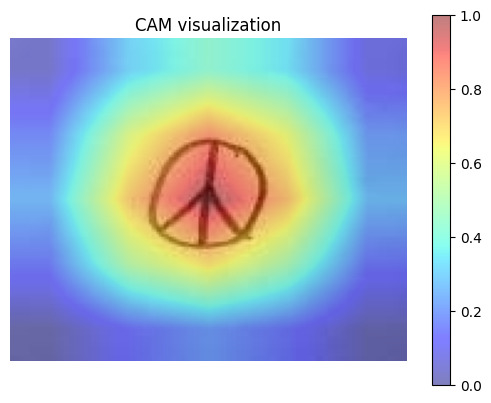

In [25]:
X, y = next(iter(test_loader))
for i in range(2):
    cam = compute_cam(model, X[i], y[i], device)
    cam = visualizer.preprocess_cam(cam)
    visualizer.show_cam(cam, X[i])

### Wrong Predictions

Correct label CAM: smiley


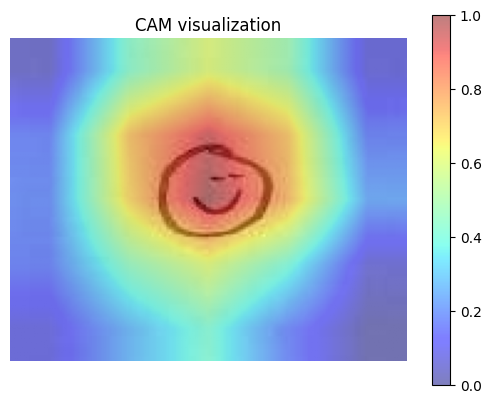

Predicted label CAM: spiral


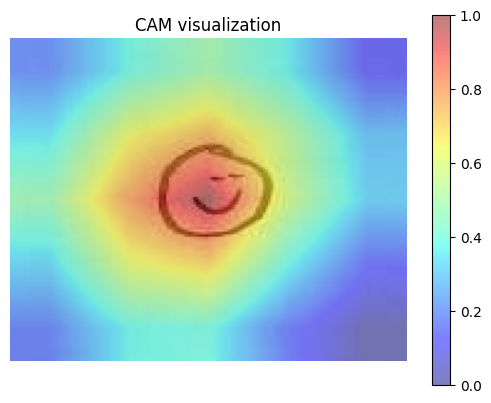

Correct label CAM: anchor


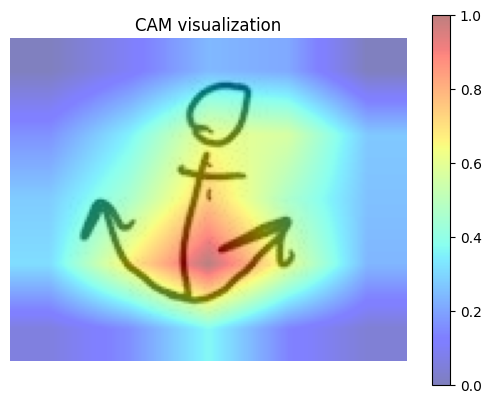

Predicted label CAM: thumb


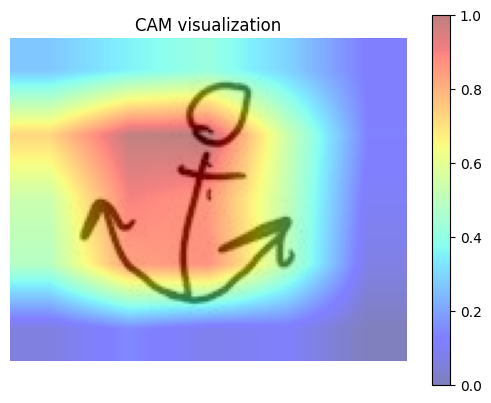

In [26]:
for i, idx in enumerate(wrong_idxs):
    if i == 2:
        break

    img_tensor = test_set[idx][0]
    img_raw = X_test[idx]

    print(f"Correct label CAM: {num_to_class[targets[idx]]}")
    cam = compute_cam(model_fb, img_tensor, targets[idx], device)
    cam = visualizer.preprocess_cam(cam)
    visualizer.show_cam(cam, img_raw)

    print(f"Predicted label CAM: {num_to_class[predictions[idx]]}")
    cam = compute_cam(model_fb, img_tensor, predictions[idx], device)
    cam = visualizer.preprocess_cam(cam)
    visualizer.show_cam(cam, img_raw)

## Results
Both approaches achieve high performance. The fully retrained model achieves perfect accuracy of 1.0, correctly classifying all images in the test set. The frozen backbone model achieves accuracy of around 0.92, missclassifying a small number of samples. This indicates that its feature representations are less effective.
## Error analysis
The results suggest, that data is very simple with low variability and is easy to learn for the models.
During the project, several important problems were identified:
- Arrays that are transformed using Laplacian have to be of signed float type, otherwise it can lead to misleading results.
- Data augmentation increases the difficulty of training task, which can result in lower training accuracy than validation accuracy.
- Channel duplication is crucial when working with grayscale images and models like ResNet, taht expect 3 channel images on input
## Summary
The goal of this experiment was to load the kaggle images dataset, process and augment the data, train it on ResNet model both fully retrained and obly last layer retrained and evaluate, which approach is a better feature extraction. The results show that fully retrained model outperforms frozen backbone model. Allowing the model to fully adapt all layers leads to better feature representation. However, good performance in both approaches showed, that dataset is very simple. Future work could include comparing additional model architectures and evaluating the model on more challenging data.